In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from qubo_utils import build_Q, check_validity,execute_qaoa_and_get_results

edges = [
    (0,1),
    (0,2),
    (1,2),
    (1,3),
    (2,3),
    (2,4),
    (3,4)
]

edge_names = ["01","02","12","13","23","24","34"]

costs = [2,4,1,3,2,5,1]

nodes = [0,1,2,3,4]

targets = {
    0: 1,   # source
    4: -1,  # sink
    1: 0,
    2: 0,
    3: 0
}

Q = build_Q(costs, edges, nodes, targets)
print(Q.shape)
print(Q)

(7, 7)
[[   2.  400. -400. -400.    0.    0.    0.]
 [   0.    4.  400.    0. -400. -400.    0.]
 [   0.    0.  401.  400. -400. -400.    0.]
 [   0.    0.    0.  403.  400.    0. -400.]
 [   0.    0.    0.    0.  402.  400. -400.]
 [   0.    0.    0.    0.    0.    5.  400.]
 [   0.    0.    0.    0.    0.    0.    1.]]


The constructed 7×7 QUBO matrix is used as input for QAOA.

In [2]:
from qat.opt import QUBO
import numpy as np

# Make Q symmetric
Q = -((Q + Q.T) / 2)

print("Q matrix:")
print(Q)

# Create QUBO object
qubo = QUBO(Q)

Q matrix:
[[  -2. -200.  200.  200.   -0.   -0.   -0.]
 [-200.   -4. -200.   -0.  200.  200.   -0.]
 [ 200. -200. -401. -200.  200.  200.   -0.]
 [ 200.   -0. -200. -403. -200.   -0.  200.]
 [  -0.  200.  200. -200. -402. -200.  200.]
 [  -0.  200.  200.   -0. -200.   -5. -200.]
 [  -0.   -0.   -0.  200.  200. -200.   -1.]]


The matrix is made symmetric and its sign is flipped to convert the problem into a maximization form required by QAOA.Finally, the matrix is converted into a QUBO object.    

In [3]:
# Convert to Ising
# ising = qubo.to_ising()

# Create QAOA job (2 layers)
job = qubo.qaoa_job(2,False)
# Display circuit
job.circuit.display()

A QAOA job is created from the QUBO model using 2 layers(depth = 2).The circuit corresponding to this QAOA job is then generated and displayed to visualize the quantum operations.

In [4]:
from qat.qpus import get_default_qpu
#Initialize QPU
qpu = get_default_qpu()

result = qpu.submit(job)

#print(result)
print("Optimal parameters:", result.parameter_map)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optimal parameters: {'\\beta_{0}': -0.6136703632307784, '\\beta_{1}': 0.488891443243664, '\\gamma_{0}': 0.06706679608833654, '\\gamma_{1}': 0.08307463650715861}


A default QPU (simulator) is initialized and used to execute the QAOA job.The resulting optimized parameters are then retrieved and printed.

In [5]:
param_map = result.parameter_map

bitstrings, probabilities, final_result = execute_qaoa_and_get_results(job, qpu, param_map, Q,nbshots=0)
print(bitstrings)
print(probabilities)

['0000000', '0000001', '0000010', '0000011', '0000100', '0000101', '0000110', '0000111', '0001000', '0001001', '0001010', '0001011', '0001100', '0001101', '0001110', '0001111', '0010000', '0010001', '0010010', '0010011', '0010100', '0010101', '0010110', '0010111', '0011000', '0011001', '0011010', '0011011', '0011100', '0011101', '0011110', '0011111', '0100000', '0100001', '0100010', '0100011', '0100100', '0100101', '0100110', '0100111', '0101000', '0101001', '0101010', '0101011', '0101100', '0101101', '0101110', '0101111', '0110000', '0110001', '0110010', '0110011', '0110100', '0110101', '0110110', '0110111', '0111000', '0111001', '0111010', '0111011', '0111100', '0111101', '0111110', '0111111', '1000000', '1000001', '1000010', '1000011', '1000100', '1000101', '1000110', '1000111', '1001000', '1001001', '1001010', '1001011', '1001100', '1001101', '1001110', '1001111', '1010000', '1010001', '1010010', '1010011', '1010100', '1010101', '1010110', '1010111', '1011000', '1011001', '1011010'

The optimized QAOA parameters are retrieved and assigned to the circuit.The resulting circuit is executed on the QPU with 2000 shots to obtain measurement outcomes.The measured bitstrings and their corresponding probabilities are collected and printed.

In [6]:
costs_list = []
valid_flags = []

num_edges = len(edges)

for sample in final_result:

    bitstring = sample.state.bitstring.zfill(Q.shape[0])

    edge_bits = bitstring[:num_edges]

    bits = [int(b) for b in edge_bits]   # convert to list of ints

    #selected_edges = [edges[i] for i, b in enumerate(bits) if b == 1]

    path_cost = sum(costs[i] for i, b in enumerate(bits) if b == 1)

    valid = check_validity(bits, edges, nodes, targets)

    costs_list.append(path_cost)
    valid_flags.append(valid)

for b, c, v, p in zip(bitstrings, costs_list, valid_flags,probabilities):
  if v:
    print("Bitstring:", b, "| Path cost:", c,"| Probability:", p,"| Valid:",v)

Bitstring: 0100010 | Path cost: 9 | Probability: 0.11204879829054196 | Valid: True
Bitstring: 0100101 | Path cost: 7 | Probability: 0.117204571660227 | Valid: True
Bitstring: 1001001 | Path cost: 6 | Probability: 0.11253380261891215 | Valid: True
Bitstring: 1010010 | Path cost: 8 | Probability: 0.11547830369370925 | Valid: True
Bitstring: 1010101 | Path cost: 6 | Probability: 0.12411869723297045 | Valid: True


Each measured bitstring is processed to compute the corresponding path cost and check its validity based on the given constraints. The results are stored and only the valid solutions along with their costs and probabilities are displayed.

In [7]:
best_cost = float('inf')
best_bitstring = None
best_prob = -1

# Find the best valid solution
for c, v, b, p in zip(costs_list, valid_flags, bitstrings, probabilities):
    if v:
        if (c < best_cost) or (c == best_cost and p > best_prob):
            best_cost = c
            best_bitstring = b
            best_prob = p
# Print best solution 
print("Best valid bitstring:", best_bitstring)
print("Best valid cost:", best_cost)

if best_bitstring is not None:
    bits = [int(b) for b in best_bitstring]
    edge_bits = bits[:num_edges]

    best_path_edges = [
    edges[i] for i, b in enumerate(edge_bits) if b == 1
    ]

    print("Best valid path :", best_path_edges)
else:
    print("No valid solution found")
    
print("Probability of best solution:", best_prob)

Best valid bitstring: 1010101
Best valid cost: 6
Best valid path : [(0, 1), (1, 2), (2, 3), (3, 4)]
Probability of best solution: 0.12411869723297045


The valid solution with the minimum cost is identified using the computed costs_list, valid_flags and bitstrings.Its corresponding probability is obtained from probabilities and the bitstring is used to extract the selected edges representing the path.The best valid solution along with its cost, path and probability is displayed.

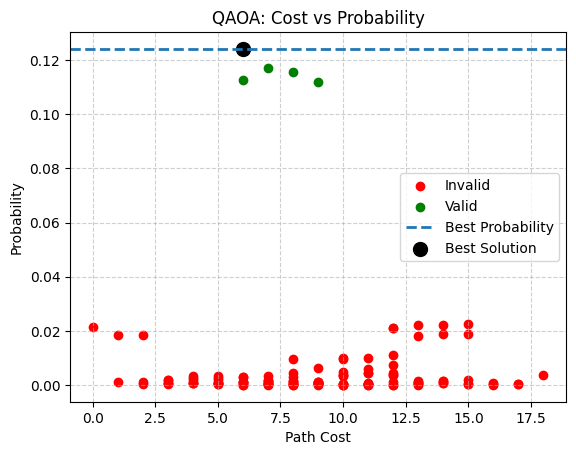

In [8]:
import matplotlib.pyplot as plt

# valid
valid_x = [c for c, v in zip(costs_list, valid_flags) if v]
valid_y = [p for p, v in zip(probabilities, valid_flags) if v]

# invalid
invalid_x = [c for c, v in zip(costs_list, valid_flags) if not v]
invalid_y = [p for p, v in zip(probabilities, valid_flags) if not v]

# Plot
plt.scatter(invalid_x, invalid_y, color='red', label='Invalid')
plt.scatter(valid_x, valid_y, color='green', label='Valid')


# mark best probability 
if best_prob is not None:
    plt.axhline(y=best_prob, linestyle='--', linewidth=2, label='Best Probability')

# Plot the optimal solution point
    plt.scatter(best_cost, best_prob, s=100, color='black', label='Best Solution')

plt.xlabel("Path Cost")
plt.ylabel("Probability")
plt.title("QAOA: Cost vs Probability")

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

The costs and probabilities are plotted for both valid and invalid solutions using a scatter plot. The best solution is highlighted based on its cost and probability, providing a clear view of the QAOA results.